In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

from configurations import load_data, set_font_sizes, create_fig, apply_general_styles, save_fig
from configurations.plot_config import FONTSIZES

apply_general_styles()

# Test induction head

In [77]:
# Load picke

data = load_data('temp',experiment_name='tmp')

for key, value in data.items():
    print(f"{key}: {value.shape}")


# data['input']

File temp.pkl loaded with pickle.load from /u/c/cerazova/SAM/data/tmp
S1: (10, 15, 15)
A1: (10, 15, 15)
Y1: (10, 15, 1000)
S2: (10, 15, 15)
A2: (10, 15, 15)
Y2: (10, 15, 1000)
X2: (10, 15, 1000)
Y3: (10, 15, 1000)
X3: (10, 15, 1000)
logits: (10, 15, 20)
logits_X2: (10, 15, 20)
logits_Y3: (10, 15, 20)
input: (10, 15)


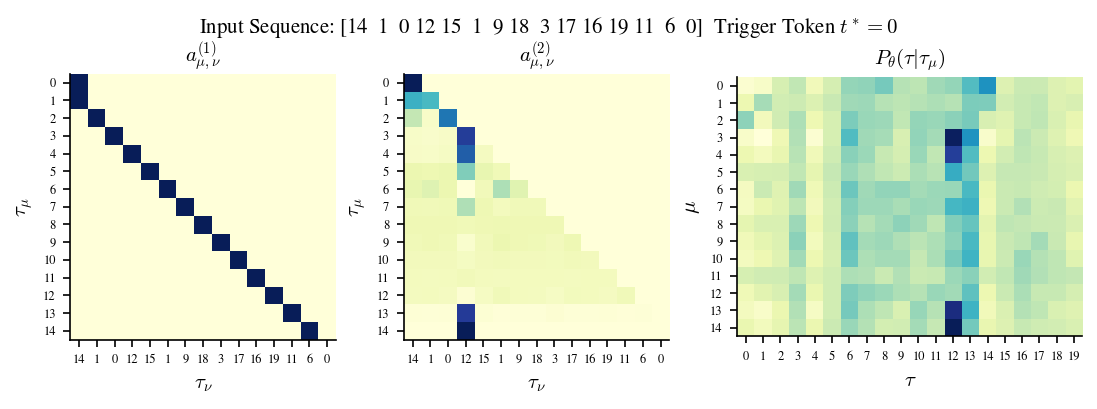

Figure saved on /u/c/cerazova/SAM/plots/2026-03 as dual_task.png


In [104]:
# Settings
i_batch = 6
cmap = 'YlGnBu'

set_font_sizes(conf='tight')

# Plots
fig , axes = create_fig(ncols=3,size='double',h=0.35,w=1,w_ratios=[1,1,1.3],
                        sharex=False, sharey=False)

for i , ax in enumerate(axes[:2]):
    A = data[f'A{i+1}'][i_batch]  # shape (seq_len, seq_len)
    ax.set_title(rf'$a^{{({i+1})}}_{{\mu,\nu}}$')
    ax.set_xlabel(r'$\tau_\nu$')
    ax.set_ylabel(r'$\tau_\mu$')
    input = data['input'][i_batch]
    im = ax.imshow(A, cmap=cmap)#,vmax=0.3)
    # plt.colorbar(im, ax=ax)
    ax.set_xticks(np.arange(A.shape[0]),input)
    ax.set_yticks(np.arange(A.shape[0]))

ax = axes[2]
log = 0.5*data['logits'][i_batch] # shape (seq_len, vocab_size)
P = np.exp(log) / np.exp(log).sum(axis=-1, keepdims=True)  # shape (seq_len, vocab_size)
im = ax.imshow(P, cmap=cmap)#,vmax=0.3)
# plt.colorbar(im, ax=ax)
ax.set_ylabel(r'$\mu$')
ax.set_xlabel(r'$\tau$')
ax.set_title(r'$P_\theta(\tau|\tau_\mu)$')
ax.set_xticks(np.arange(log.shape[1]))
ax.set_yticks(np.arange(log.shape[0]))

fig.suptitle(f'Input Sequence: {data["input"][i_batch]} '+r' Trigger Token $t^*=0$')
plt.show()

save_fig(fig,'dual_task',date=True)


# Check loss

In [43]:
d = 1024
alpha = 2

data = load_data('dual_task_check',experiment_name='tmp',params={'d_model':d,'alpha':alpha})

for key in data.keys():
    data[key] = np.array(data[key])
    print(f"{key}: {data[key].shape}")

File dual_task_check_alpha2_d_model1024.pkl loaded with pickle.load from /u/c/cerazova/SAM/data/tmp
V_values: (10,)
loss: (10,)
accuracy: (10,)
entropy_P_u: (10,)
max_entropy: (10,)


Text(0.35, 0.15, '$\\sqrt{d}$')

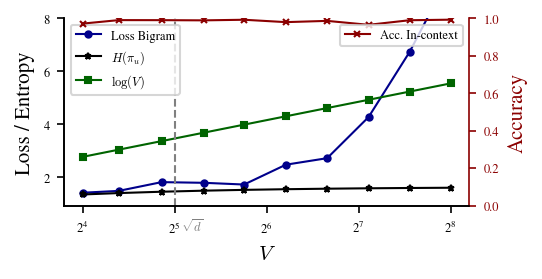

In [44]:
# Settings

set_font_sizes(conf='tight')


# Plot
fig , axes = create_fig()

ax = axes 
ax.spines['right'].set_visible(True)
ax.spines['right'].set_color('darkred')
ax.set_xlabel(r'$V$')
ax.set_ylabel('Loss / Entropy')
ax.set_xscale('log',base=2)
ax.plot(data['V_values'],data['loss'],label='Loss Bigram',color='darkblue',marker='o',markersize=3,lw=1)
ax.plot(data['V_values'],data['entropy_P_u'],label=r'$H(\pi_u)$',color='black',marker='*',markersize=3,lw=1)
ax.plot(data['V_values'],data['max_entropy'],label=r'$\log(V)$',color='darkgreen',marker='s',markersize=3,lw=1)
ax.legend(loc=2)
ax.axvline(math.sqrt(d),color='gray',ls='--',label=r'$\sqrt{d}$',lw=1)
ax.set_ylim(top=8)

ax_twin = ax.twinx()
ax_twin.set_ylabel(r'Accuracy',color='darkred')
ax_twin.plot(data['V_values'],data['accuracy'],color='darkred',label='Acc. In-context',marker='x',markersize=3,lw=1)
ax_twin.legend(loc=1)
ax_twin.set_ylim(0,1)
# color the axis red
ax_twin.tick_params(axis='y', colors='darkred')

fig.text(0.35,0.15,r'$\sqrt{d}$',color='gray',ha='center',size=FONTSIZES['xs'])

# save_fig(fig,'dual_task_check',params={'d':d,'alpha':alpha,'L':256,'K':10},date=True)

In [14]:
math.sqrt(d)

45.254833995939045

# Bi vs ind loss

In [53]:
d = 2048
alpha = 2
vocab_size = 32

data = load_data('dual_task_compare_loss',experiment_name='tmp',params={'d_model':d,'alpha':alpha})

for key in data.keys():
    data[key] = np.array(data[key])
    print(f"{key}: {data[key].shape}")

File dual_task_compare_loss_alpha2_d_model2048.pkl loaded with pickle.load from /u/c/cerazova/SAM/data/tmp
K_values: (8,)
loss_bi: (8,)
loss_ind: (8,)
loss_tot: (8,)
entropy_P_u: ()
max_entropy: ()


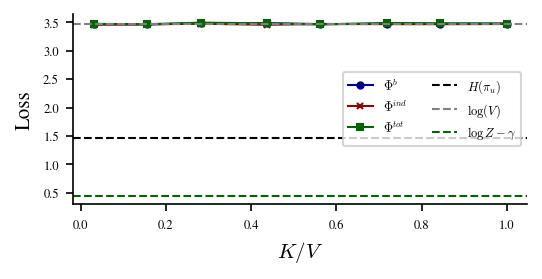

In [54]:
# Settings
set_font_sizes(conf='tight')

# Plot
fig , axes = create_fig()

ax = axes
Ks = data['K_values']/vocab_size
loss_bi = data['loss_bi']
loss_ind = data['loss_ind']
loss_tot = data['loss_tot']
ax.plot(Ks, loss_bi, label=r'$\Phi^{b}$', color='darkblue', marker='o', markersize=3, lw=1)
ax.plot(Ks, loss_ind, label='$\Phi^{ind}$', color='darkred', marker='x', markersize=3, lw=1)
ax.plot(Ks, loss_tot, label='$\Phi^{tot}$', color='darkgreen', marker='s', markersize=3, lw=1)
ax.set_xlabel(r'$K/V$')
ax.set_ylabel('Loss')
# ax.legend()

ax.axhline(data['entropy_P_u'], color='black', ls='--', label=r'$H(\pi_u)$', lw=1)
ax.axhline(data['max_entropy'], color='gray', ls='--', label=r'$\log(V)$', lw=1)
gamma = 4.0
Z = math.exp(gamma) + vocab_size - 1

ax.axhline(math.log(Z)-gamma, color='darkgreen', ls='--', label=r'$\log Z-\gamma$', lw=1)
ax.legend(ncols=2)
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_title(f'Loss vs K for d={d}, alpha={alpha}')


# save_fig(fig,'dual_task_compare_loss',params={'d':d,'alpha':alpha,'L':256,'V':vocab_size},date=True)

In [34]:
np.logspace(-0.1,np.log10(vocab_size),num=10,dtype=int)

array([ 0,  1,  1,  2,  4,  7, 11, 17, 27, 42])

In [23]:
gamma = 4.0
Z = math.exp(gamma) + vocab_size - 1
print(-gamma + math.log(Z))

0.5601534687523824
